# Matthew Drew
## Project 1
## OPAN-6603: Advanced ML and Intro to AI
## January 19, 2026

## Import Packages and Data
---

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

In [3]:
# upload data to colab
from google.colab import files
uploaded = files.upload()

Saving Employee_Data_Project.xlsx to Employee_Data_Project.xlsx


In [4]:
data = pd.read_excel("Employee_Data_Project.xlsx")

RANDOM_STATE = 6603

## Step 1: Examine data
---

In [5]:
print(data.head)

<bound method NDFrame.head of       Age Attrition     BusinessTravel  DistanceFromHome  Education  \
0      51        No      Travel_Rarely                 6          2   
1      31       Yes  Travel_Frequently                10          1   
2      32        No  Travel_Frequently                17          4   
3      38        No         Non-Travel                 2          5   
4      32        No      Travel_Rarely                10          1   
...   ...       ...                ...               ...        ...   
4405   42        No      Travel_Rarely                 5          4   
4406   29        No      Travel_Rarely                 2          4   
4407   25        No      Travel_Rarely                25          2   
4408   42        No      Travel_Rarely                18          2   
4409   40        No      Travel_Rarely                28          3   

      EmployeeID  Gender  JobLevel MaritalStatus  Income  NumCompaniesWorked  \
0              1  Female         1   

In [6]:
print(data.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DistanceFromHome             int64
Education                    int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
MaritalStatus               object
Income                       int64
NumCompaniesWorked         float64
StandardHours                int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsWithCurrManager         int64
EnvironmentSatisfaction    float64
JobSatisfaction            float64
dtype: object


In [7]:
print(data.info)

<bound method DataFrame.info of       Age Attrition     BusinessTravel  DistanceFromHome  Education  \
0      51        No      Travel_Rarely                 6          2   
1      31       Yes  Travel_Frequently                10          1   
2      32        No  Travel_Frequently                17          4   
3      38        No         Non-Travel                 2          5   
4      32        No      Travel_Rarely                10          1   
...   ...       ...                ...               ...        ...   
4405   42        No      Travel_Rarely                 5          4   
4406   29        No      Travel_Rarely                 2          4   
4407   25        No      Travel_Rarely                25          2   
4408   42        No      Travel_Rarely                18          2   
4409   40        No      Travel_Rarely                28          3   

      EmployeeID  Gender  JobLevel MaritalStatus  Income  NumCompaniesWorked  \
0              1  Female         1 

In [8]:
print(data.shape)

(4410, 18)


In [9]:
print(data.describe())

               Age  DistanceFromHome    Education   EmployeeID     JobLevel  \
count  4410.000000       4410.000000  4410.000000  4410.000000  4410.000000   
mean     36.923810          9.192517     2.912925  2205.500000     2.063946   
std       9.133301          8.105026     1.023933  1273.201673     1.106689   
min      18.000000          1.000000     1.000000     1.000000     1.000000   
25%      30.000000          2.000000     2.000000  1103.250000     1.000000   
50%      36.000000          7.000000     3.000000  2205.500000     2.000000   
75%      43.000000         14.000000     4.000000  3307.750000     3.000000   
max      60.000000         29.000000     5.000000  4410.000000     5.000000   

              Income  NumCompaniesWorked  StandardHours  TotalWorkingYears  \
count    4410.000000         4391.000000         4410.0        4401.000000   
mean    65029.312925            2.694830            8.0          11.279936   
std     47068.888559            2.498887            0.

In [10]:
print(data.isna().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DistanceFromHome            0
Education                   0
EmployeeID                  0
Gender                      0
JobLevel                    0
MaritalStatus               0
Income                      0
NumCompaniesWorked         19
StandardHours               0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsWithCurrManager        0
EnvironmentSatisfaction    25
JobSatisfaction            20
dtype: int64


## Step 2: Split data into train and test sets
---

In [11]:
train, test = train_test_split(
    data,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=data['Attrition']
)

print("Train shape:", train.shape)
print("Test shape: ", test.shape)


# Heavy class imbalance
print("\nTrain target rate:", train['Attrition'].map({'No': 0, 'Yes': 1}).astype(int).mean())
print("Test target rate: ", test['Attrition'].map({'No': 0, 'Yes': 1}).astype(int).mean())

Train shape: (3087, 18)
Test shape:  (1323, 18)

Train target rate: 0.16132167152575316
Test target rate:  0.16099773242630386


## Step 3: Exploratory data analysis
---

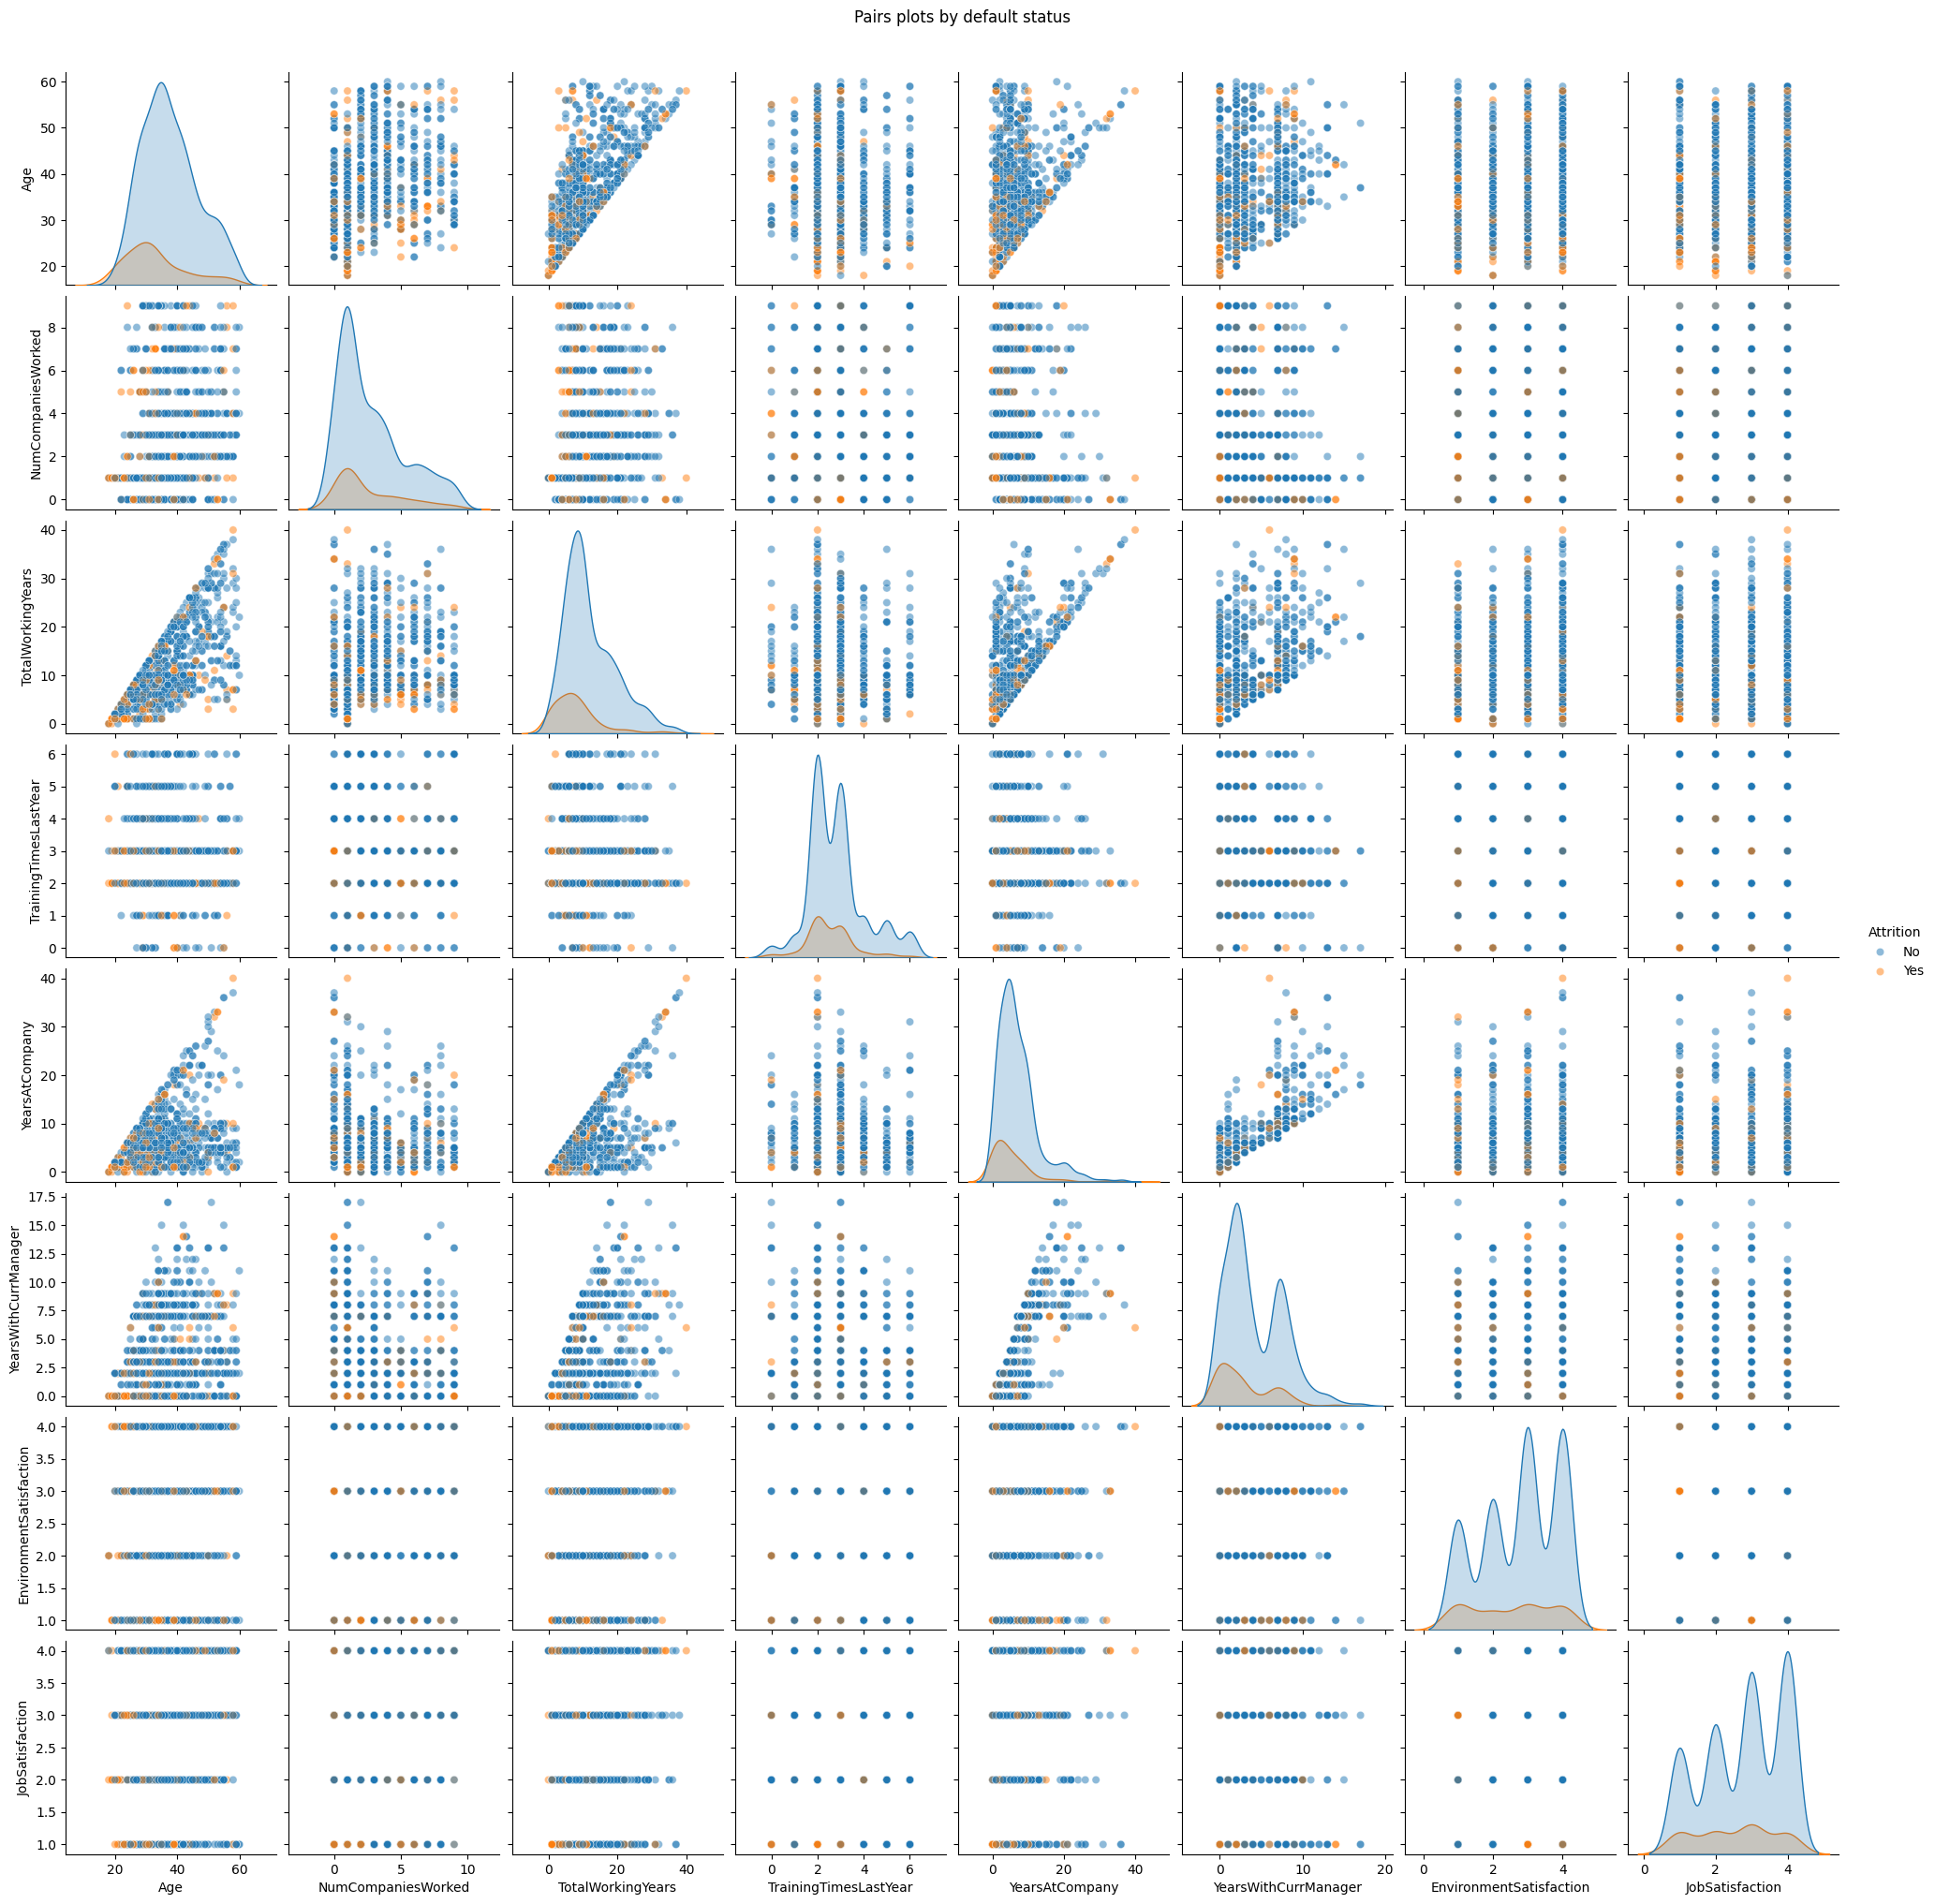

In [12]:
plot_sample = train.sample(
    n=1000,
    random_state=RANDOM_STATE
)

# choose a few numeric columns to pairplot (adjust as needed)
numeric_cols = [
    "Age",
    "NumCompaniesWorked",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsWithCurrManager",
    "EnvironmentSatisfaction",
    "JobSatisfaction"]

sns.pairplot(
    plot_sample,
    vars=numeric_cols,
    hue='Attrition',
    plot_kws={"alpha": 0.5}
)
plt.suptitle("Pairs plots by default status", y=1.02)
plt.show()

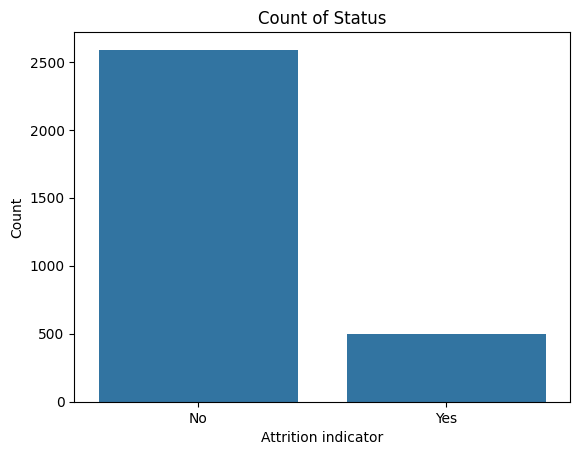

In [13]:
# Basic bar plot of Attrition
sns.countplot(data=train, x="Attrition")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Status")
plt.show()

## Step 4: Feature engineering
---

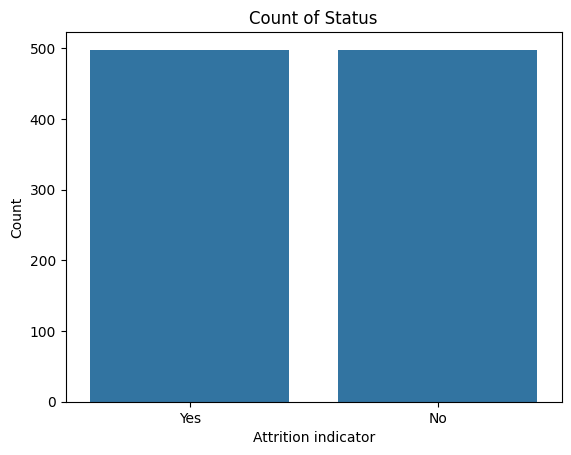

In [14]:
# Drop original Income, refit rf_pipeline on X_train_bal with Income_log
data['Income_log'] = np.log1p(data['Income'])

# Class imbalance: downsample the negative class; keep all positives
# + equal number of negatives
pos_idx = train.index[train["Attrition"] == "Yes"]
neg_idx = train.index[train["Attrition"] == "No"]

keep_neg = np.random.choice(neg_idx, size=len(pos_idx), replace=False)
keep_idx = np.concatenate([pos_idx, keep_neg])

train_bal = train.loc[keep_idx].copy()

# Quick look after balancing
sns.countplot(data=train_bal, x="Attrition")
plt.xlabel("Attrition indicator")
plt.ylabel("Count")
plt.title("Count of Status")
plt.show()

In [15]:
# Split into X (features) and y (target)
X_train_bal = train_bal.drop(columns=["EmployeeID", "Attrition"])
y_train_bal = train_bal["Attrition"]

X_train = train.drop(columns=["EmployeeID", "Attrition"])
y_train = train["Attrition"]

X_test = test.drop(columns=["EmployeeID", "Attrition"])
y_test = test["Attrition"]

# Preprocessing:
# - Numeric: KNN imputation (covers MonthlyIncome and Num_dependents, plus any other numeric missingness)
# - Categorical (if any): most-frequent imputation + one-hot encoding
numeric_selector = make_column_selector(dtype_include=np.number)
categorical_selector = make_column_selector(dtype_exclude=np.number)

numeric_preprocess = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),    #Using KNN over median for better estimation of likely values
        ("scaler", StandardScaler())
    ]
)

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_selector),
        ("cat", categorical_preprocess, categorical_selector),
    ],
    remainder="drop"
)

print("X_train shape:", X_train.shape)
print("y_train mean:", y_train.map({'No': 0, 'Yes': 1}).mean())


X_train shape: (3087, 16)
y_train mean: 0.16132167152575316


## Step 5: Feature and Model selection
---

In [16]:
def evaluate_classifier(name, estimator, X_train, y_train, X_test, y_test):
    estimator.fit(X_train, y_train)
    yhat_train = estimator.predict(X_train)
    yhat_test = estimator.predict(X_test)

    # probabilities
    train_auc = test_auc = np.nan
    if hasattr(estimator, "predict_proba"):
        p_train = estimator.predict_proba(X_train)[:, 1]
        p_test = estimator.predict_proba(X_test)[:, 1]
        train_auc = roc_auc_score(y_train, p_train)
        test_auc = roc_auc_score(y_test, p_test)

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, yhat_train),
        "test_accuracy": accuracy_score(y_test, yhat_test),
        "train_precision": precision_score(y_train, yhat_train, pos_label="Yes"),
        "test_precision": precision_score(y_test, yhat_test, pos_label="Yes"),
        "train_recall": recall_score(y_train, yhat_train, pos_label="Yes"),
        "test_recall": recall_score(y_test, yhat_test, pos_label="Yes"),
        "train_f1": f1_score(y_train, yhat_train, pos_label="Yes"),
        "test_f1": f1_score(y_test, yhat_test, pos_label="Yes"),
        "train_roc_auc": train_auc,
        "test_roc_auc": test_auc,
    }
    return estimator, results

### 5A) Random Forest (primary)

In [26]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            oob_score=True
        ))
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 10, 15]
}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train_bal, y_train_bal)
rf_pipeline = rf_grid.best_estimator_

rf_pipeline, res_rf = evaluate_classifier(
    "Random Forest",
    rf_pipeline,
    X_train, y_train, X_test, y_test
)

In [28]:
print("Best params:", rf_grid.best_params_)
print("Best CV AUC:", rf_grid.best_score_)

Best params: {'model__max_depth': 15, 'model__n_estimators': 300}
Best CV AUC: 0.9379658585858586


### 5B) Artificial Neural Network


In [19]:
mlp_pipe = Pipeline([
    ("preprocess", preprocess),
    ("classifier", MLPClassifier(
        random_state=RANDOM_STATE,
        early_stopping = False,              #probably will not change
        solver = "adam",                     #probably will not change
        activation = "relu",                 #probably will not change
        validation_fraction = 0.2            #Default ~ 0.1 Tradeoff: larger fractions give more stable validation signals but leave less data for fitting; smaller fractions give more training data but a noisier validation curve
        )
    )
])

param_grid = {
    "classifier__hidden_layer_sizes": [
        (10,),
        (10, 10),
        (10, 10, 10)
    ],
    "classifier__alpha": [
        1e-5,
        1e-4,
        1e-3,
        1e-2
    ],
    "classifier__max_iter": [
        1000,
        3000,
        5000
    ],
    "classifier__learning_rate_init": [
        .1,
        .01,
        .001
    ],
    "classifier__n_iter_no_change": [
        10,
        15,
        20
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
    )

grid_search = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train_bal, y_train_bal)
best_mlp = grid_search.best_estimator_

best_mlp, res_mlp = evaluate_classifier(
    "MLP (tuned)",
    best_mlp,
    X_train, y_train, X_test, y_test
)

In [20]:
print("Best params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

Best params: {'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (10, 10, 10), 'classifier__learning_rate_init': 0.01, 'classifier__max_iter': 1000, 'classifier__n_iter_no_change': 20}
Best CV AUC: 0.860780707070707


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


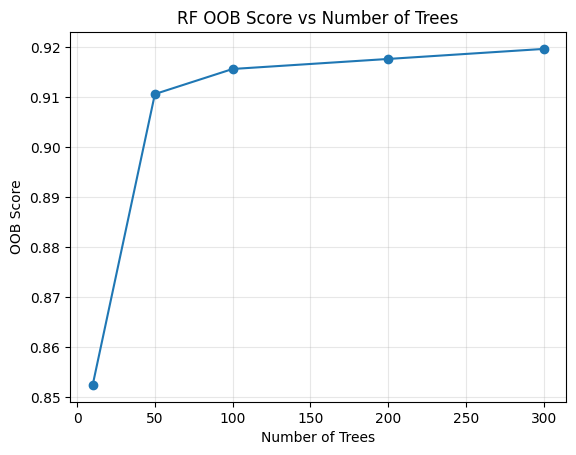

In [31]:
oob_scores = []
n_estimators_list = [10, 50, 100, 200, 300]

for n in n_estimators_list:
    rf_tmp_pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=n,
            max_depth=rf_grid.best_params_.get("model__max_depth", None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            oob_score=True
        ))
    ])
    rf_tmp_pipe.fit(X_train_bal, y_train_bal)
    oob_scores.append(rf_tmp_pipe.named_steps["model"].oob_score_)

plt.figure()
plt.plot(n_estimators_list, oob_scores, marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Score")
plt.title("RF OOB Score vs Number of Trees")
plt.grid(True, alpha=0.3)
plt.show()

### Look at the final comparison

In [32]:
results_df = pd.DataFrame([res_rf, res_mlp])
results_df

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,Random Forest,0.999352,0.987906,1.000000,1.000000,0.995984,0.924883,0.997988,0.960976,1.000000,0.999484
1,MLP (tuned),0.943311,0.922147,0.944904,0.910448,0.688755,0.572770,0.796748,0.703170,0.959925,0.914207


## Step 6: Predictions and final model evaluation
---

In [ ]:
# ------------------------------------------------------------
# Helper: get transformed feature names from the ColumnTransformer
# ------------------------------------------------------------
def get_preprocessed_feature_names(preprocess, X_sample):
    """Return feature names after preprocessing.

    Works for:
    - numeric passthrough / numeric pipeline
    - categorical pipeline with OneHotEncoder
    """
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        # Fallback: fit on sample and build names manually (older sklearn)
        preprocess.fit(X_sample)
        return preprocess.get_feature_names_out()

### 6A) Random Forest interpretability: importance + PDP

In [ ]:
rf_model = rf_pipeline.named_steps["model"]
rf_pre = rf_pipeline.named_steps["preprocess"]

feat_names = get_preprocessed_feature_names(rf_pre, X_train)
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)

# Plot top 15
plot_df = imp_df.iloc[::-1]  # reverse for horizontal bar plot

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Post Analysis

In [ ]:
top_features = ['Income', 'Age', 'TotalWorkingYears', 'DistanceFromHome', 'YearsAtCompany', 'NumCompaniesWorked', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'TrainingTimesLastYear', 'Education','JobLevel']

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="Age",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
print(data.groupby("Attrition")["Age"].mean())

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="Income",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
print(data.groupby("Attrition")["Income"].mean())

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="TotalWorkingYears",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="DistanceFromHome",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="YearsAtCompany",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="NumCompaniesWorked",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="YearsWithCurrManager",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="EnvironmentSatisfaction",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="JobSatisfaction",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="Education",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="TrainingTimesLastYear",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
for col in data.columns:
  sns.kdeplot(
    data=data,
    x="JobLevel",
    hue=data["Attrition"],
    fill=True,
    common_norm=False
  )

In [ ]:
#Bucket the ages
age_labels = []

for age in data['Age']:
    if age < 30:
        age_labels.append('<30')
    elif 30 <= age < 40:
        age_labels.append('30-39')
    elif 40 <= age < 50:
        age_labels.append('40-49')
    else:
        age_labels.append('50+')

data['Age_label'] = age_labels

#Bucket income
income_labels = []

for income in data['Income']:
    if income < 30000:
        income_labels.append('Less than $30k')
    elif 30000 <= income < 50000:
        income_labels.append('$30k - $50k')
    elif 50000 <= income < 75000:
        income_labels.append('$50k - $75k')
    elif 75000 <= income < 100000:
        income_labels.append('$75k - $100k')
    elif 100000 <= income < 150000:
        income_labels.append('$100k - $150k')
    else:
        income_labels.append('$150k or more')

data['Income_label'] = income_labels

#Bucket company tenure
tenure_labels = []

for tenure in data['YearsAtCompany']:
    if tenure < 4:
        tenure_labels.append('0-3: Short-Term')
    elif 4 <= tenure < 13:
        tenure_labels.append('4-12: Mid-Term')
    else:
        tenure_labels.append('13+: Long-Term')

data['Tenure_label'] = tenure_labels

#Transform Attrition into numeric for analysis
data['Attrition'] = data['Attrition'].map({"No": 0, "Yes": 1})

In [ ]:
age = pd.DataFrame(data.groupby("Age_label")["Attrition"].mean().sort_values(ascending=False))
income = pd.DataFrame(data.groupby("Income_label")["Attrition"].mean().sort_values(ascending=False))
tenure = pd.DataFrame(data.groupby("Tenure_label")["Attrition"].mean().sort_values(ascending=False))
training = pd.DataFrame(data.groupby("TrainingTimesLastYear")["Attrition"].mean().sort_values(ascending=False))

In [ ]:
print(training)

In [ ]:
print(age)

In [ ]:
print(income)

In [ ]:
print(tenure)

In [ ]:
sns.barplot(data=age, x="Age_label", y="Attrition")
plt.xlabel("Age")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Age")
plt.show()

In [ ]:
sns.barplot(data=income, x="Income_label", y="Attrition")
plt.xlabel("Income")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Income")
plt.show()

In [ ]:
sns.barplot(data=tenure, x="Tenure_label", y="Attrition")
plt.xlabel("Company Tenure")
plt.ylabel("Attrition Rate")
plt.title("Attrition Rate by Company Tenure")
plt.show()

In [ ]:
import plotly.graph_objects as go

# Define nodes and links
labels = ['Short-Term (0-3 yrs)', 'Mid-Term (4-12 yrs)', 'Long-Term (13+ yrs)', 'Stay', 'Leave']
source = [0, 1, 2, 0, 1, 2]  # From each tenure stage
target = [3, 3, 3, 4, 4, 4]  # To Stay (index 3) or Leave (index 4)
values = [74.04, 87.87, 91.00, 25.96, 12.13, 9.00]  # Stay % then attrition %

fig = go.Figure(data=[go.Sankey(
    node = dict(
        label = labels,
        color = 'lightblue',
        colorsrc = 'Blues',
        customdata = values[:3] + [sum(values[:3]), sum(values[3:])],
        hovertemplate='%{label}: %{customdata:.1f}%<extra></extra>'
    ),
    link = dict(
        source = source,
        target = target,
        value = values,
        color = ['lawngreen' if i < 3 else 'red' for i in range(6)]
    )
)])

fig.update_layout(
    title_text="Employee Attrition by Tenure Stage",
    font_size=12,
    width=800,
    height=500
)
fig.show()  # Displays interactive chart in Jupyter/Colab

In [ ]:
import plotly.graph_objects as go

labels = [
    "Join (0-3 yrs)", "Progress to 4-12 yrs", "Attrite (0-3)",
    "Progress to 13+ yrs", "Attrite (4-12)", "Long-Term (13+ yrs)", "Attrite (13+)"
]
source = [0, 0, 1, 1, 3, 3]  # Links from prior stages
target = [1, 2, 3, 4, 5, 6]  # To next stage or attrition
value = [74.04, 25.96, 87.87, 12.13, 91.00, 9.00]  # Progression % and attrition %

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        color=["lightblue", "lightgreen", "red", "green", "orange", "darkgreen", "darkred"],
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5)
    ),
    link=dict(
        source=source, target=target, value=value,
        color=["lawngreen", "red", "lawngreen", "red", "lawngreen", "red"]
    )
)])

fig.update_layout(
    title="Employee Tenure Pipeline with Attrition",
    font=dict(size=18),
    width=900, height=500
)
fig.show()